# Data-Driven Baseline (Cotabato)

Companion to `cotabato_new_slope_unit_v2-8.ipynb`. Same dataset (`SU_17_training_v3_contri.gpkg`), same GA-EN feature subset, same 5-fold CV split, but the model is a plain MLP -- no physics layers, no soil-conditioning, no Newmark chain. Class imbalance is handled with **SMOTENC inside each fold's training partition** (validation rows untouched).

Outputs produced:
- Susceptibility distribution (OOF + held-out validation)
- Confusion matrix (OOF + validation)
- Success rate curve (OOF + validation)
- ROC / AUC (OOF + validation)
- Susceptibility map on held-out validation

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from py_files.helpers import set_seed
set_seed(42)

In [2]:
MODEL_SAVE_PATH = "/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v8_data_driven"
FILE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_17_training_v3_contri.gpkg"
VALIDATION_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data/Merged_PINN_Features_2.gpkg"
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [3]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from py_files.data import (
    preprocessing_v2, dataframe_to_dataset,
    log_transform_skewed, clip_outliers, check_feature_correlation,
    apply_log_transform, apply_clip_thresholds,
)
from py_files.train_data_driven import (
    train_data_driven, load_or_regenerate_oof_data_driven,
)
from py_files.helpers import add_soil_texture_index
from py_files.metrics import (
    plot_susceptibility_map, plot_auc, plot_confusion_matrix,
    success_rate_curve,
)

## 1. Load & Preprocess

Mirrors v8 cells: drop bookkeeping columns, slope >= 10 filter, NaN drop, log-transform skewed non-physics features, clip 1st/99th percentile, add `soil_texture_idx`. Re-uses the same transform manifest as v8 so the validation pipeline is binary-identical.

In [4]:
COLUMNS_DROP = [
    'Landslide1', 'descriptio', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction', 'sus_pinn_landslide',
    'confusion', 'landslide_preds', 'landslide_probability',
    'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC',
    'LITHO_2', 'LITHODESC_2', 'value',
]

df = gpd.read_file(FILE_PATH)
print(f"Raw dataset: {len(df)} rows")
df, columns, numeric_cols = preprocessing_v2(df, columns_drop=COLUMNS_DROP)
print(df["PGA2_max"].max())

Raw dataset: 60594 rows
  Preprocessing report:
    Starting rows:        60594  (landslide=6820)
    Dropped (Slope < 10): 0  (landslide=0)
    Columns with nulls:   {'type': np.int64(1032)}
    Dropped (NaN):        1032
    Final rows:           59562  (landslide=6615)
0.5219438672065735


In [5]:
corr_pairs = check_feature_correlation(df, numeric_cols, threshold=0.9)

  Highly correlated pairs (|r| > 0.9):
 feature_1  feature_2  correlation
Distrv_min distrd_min     0.999643


In [6]:
PHYSICS_FEATURES = {
    'Slope_mean', 'BUK_mean', 'PGA2_max',
    'Prc_mean', 'ContributingFactor_mean',
    'SoilThc_mean',
    'LULC_majority',
}
df, transformed_cols = log_transform_skewed(
    df, numeric_cols, skew_threshold=1.0, exclude=PHYSICS_FEATURES,
)
print(f"\nTransformed columns: {transformed_cols}")

    log1p(NDVI_mean)  skew was -1.67
    log1p(DistFlt_min)  skew was 1.31
    log1p(Distrv_min)  skew was 1.87
    log1p(distrd_min)  skew was 1.87

Transformed columns: ['NDVI_mean', 'DistFlt_min', 'Distrv_min', 'distrd_min']


In [7]:
outlier_cols = [c for c in numeric_cols if c not in PHYSICS_FEATURES]
df, clip_thresholds = clip_outliers(df, outlier_cols, lower_pct=1, upper_pct=99)

    Clipped Clay_mean: [313.0000, 432.9952] (1183 values)
    Clipped Sand_mean: [282.0000, 388.8641] (1185 values)
    Clipped Silt_mean: [229.0000, 358.0000] (1176 values)
    Clipped NDVI_mean: [0.3996, 0.6247] (1192 values)
    Clipped Est_mean: [-0.9935, 0.9872] (1189 values)
    Clipped Nrt_mean: [-0.9926, 0.9918] (1192 values)
    Clipped HorCurv_mean: [-0.0925, 0.0606] (1192 values)
    Clipped VertCurv_mean: [-0.0316, 0.0122] (1190 values)
    Clipped Elev_mean: [74.2448, 1939.0204] (1192 values)
    Clipped DistFlt_min: [2.3979, 9.9906] (1172 values)
    Clipped TWI_mean: [0.8862, 7.1123] (1192 values)
    Clipped Distrv_min: [0.0000, 7.8591] (596 values)
    Clipped distrd_min: [0.0000, 7.8570] (596 values)


In [8]:
df = add_soil_texture_index(df[columns].copy())
print(df.shape, list(df.columns))

(59562, 24) ['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA2_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'landslide', 'type', 'ContributingFactor_mean', 'soil_texture', 'soil_texture_idx']


## 2. Load GA-EN feature manifest

Same `v1_cotabato.json` selection as v8.

In [9]:
MANIFEST_PATH = PROJECT_ROOT / "feature_manifests" / "v1_cotabato.json"
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Feature manifest not found: {MANIFEST_PATH}. "
        "Run notebooks/feature_selection.ipynb to generate it."
    )
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

PGA_COL = manifest["pga_col"]
selected_numerical = manifest["final_features"]["numerical"]
selected_categorical = manifest["final_features"]["categorical"]
selected_feature_cols = selected_numerical + selected_categorical + ["landslide"]

print(f"Manifest:           {MANIFEST_PATH.name}")
print(f"Numerical features: {selected_numerical}")
print(f"Categorical:        {selected_categorical}")
print(f"Total inputs:       {len(selected_numerical) + len(selected_categorical)}")

Manifest:           v1_cotabato.json
Numerical features: ['Slope_mean', 'BUK_mean', 'Prc_mean', 'ContributingFactor_mean', 'SoilThc_mean', 'soil_texture_idx', 'PGA2_max', 'Elev_mean']
Categorical:        ['type']
Total inputs:       9


## 3. Train data-driven MLP with per-fold SMOTE

5-fold StratifiedKFold (same `random_state=42` as v8 so the fold splits are identical). SMOTENC is applied only to each fold's training partition; the validation partition is left untouched so OOF metrics stay unbiased. `type` and `soil_texture_idx` are flagged as categorical so SMOTENC samples discrete values instead of interpolating between texture classes.

/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


  Fold 1 SMOTE: 47649 -> 84714 rows (positives=42357/84714)


2026-05-11 11:38:05.344045: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-11 11:38:05.537332: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-11 11:38:05.924843: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200


2026-05-11 11:38:06.691628: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

  Fold 4 SMOTE: 47650 -> 84716 rows (positives=42358/84716)
dtype is a string
Epoch 1/200


2026-05-11 11:40:30.200704: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


662/662 - 3s - 5ms/step - accuracy: 0.7965 - auc: 0.8739 - loss: 0.4403 - val_accuracy: 0.8097 - val_auc: 0.8681 - val_loss: 0.3637
Epoch 2/200
662/662 - 1s - 2ms/step - accuracy: 0.8383 - auc: 0.9112 - loss: 0.3706 - val_accuracy: 0.8025 - val_auc: 0.8833 - val_loss: 0.4008
Epoch 3/200
662/662 - 1s - 2ms/step - accuracy: 0.8471 - auc: 0.9209 - loss: 0.3507 - val_accuracy: 0.8256 - val_auc: 0.8935 - val_loss: 0.3795
Epoch 4/200
662/662 - 1s - 2ms/step - accuracy: 0.8529 - auc: 0.9261 - loss: 0.3395 - val_accuracy: 0.8330 - val_auc: 0.8778 - val_loss: 0.3802
Epoch 5/200
662/662 - 1s - 2ms/step - accuracy: 0.8555 - auc: 0.9296 - loss: 0.3315 - val_accuracy: 0.8370 - val_auc: 0.8847 - val_loss: 0.3446
Epoch 6/200
662/662 - 1s - 2ms/step - accuracy: 0.8591 - auc: 0.9329 - loss: 0.3241 - val_accuracy: 0.8118 - val_auc: 0.8950 - val_loss: 0.3638
Epoch 7/200
662/662 - 1s - 2ms/step - accuracy: 0.8632 - auc: 0.9358 - loss: 0.3171 - val_accuracy: 0.8325 - val_auc: 0.8955 - val_loss: 0.3365
Epoc

/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


  Fold 5 SMOTE: 47650 -> 84716 rows (positives=42358/84716)
dtype is a string
Epoch 1/200
662/662 - 3s - 5ms/step - accuracy: 0.8085 - auc: 0.8834 - loss: 0.4237 - val_accuracy: 0.7919 - val_auc: 0.8771 - val_loss: 0.4302
Epoch 2/200
662/662 - 1s - 2ms/step - accuracy: 0.8401 - auc: 0.9141 - loss: 0.3661 - val_accuracy: 0.8458 - val_auc: 0.8885 - val_loss: 0.3507
Epoch 3/200
662/662 - 1s - 2ms/step - accuracy: 0.8499 - auc: 0.9236 - loss: 0.3458 - val_accuracy: 0.7925 - val_auc: 0.8927 - val_loss: 0.4144
Epoch 4/200
662/662 - 1s - 2ms/step - accuracy: 0.8568 - auc: 0.9287 - loss: 0.3347 - val_accuracy: 0.8282 - val_auc: 0.8879 - val_loss: 0.3720
Epoch 5/200
662/662 - 1s - 2ms/step - accuracy: 0.8604 - auc: 0.9329 - loss: 0.3247 - val_accuracy: 0.8015 - val_auc: 0.8954 - val_loss: 0.3763
Epoch 6/200
662/662 - 1s - 2ms/step - accuracy: 0.8638 - auc: 0.9357 - loss: 0.3184 - val_accuracy: 0.8250 - val_auc: 0.8988 - val_loss: 0.3426
Epoch 7/200
662/662 - 1s - 2ms/step - accuracy: 0.8668 - a

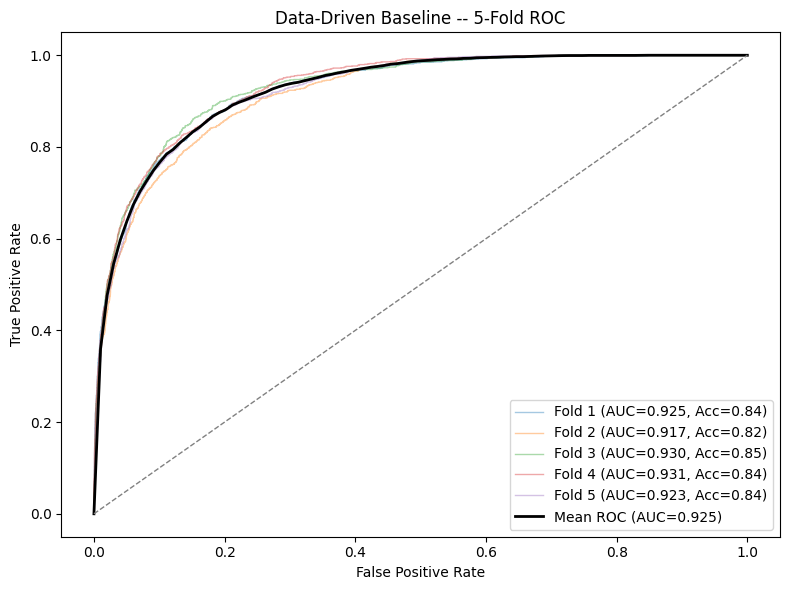


Per-fold OOF AUCs: [np.float64(0.9253), np.float64(0.9171), np.float64(0.93), np.float64(0.9308), np.float64(0.9233)]
Mean OOF AUC:      0.9253


In [10]:
oof_preds, fold_aucs = train_data_driven(
    df,
    selected_numerical,
    selected_categorical,
    selected_feature_cols,
    pga_col=PGA_COL,
    path=MODEL_SAVE_PATH,
    smote=True,
)
print(f"\nPer-fold OOF AUCs: {[round(a, 4) for a in fold_aucs]}")
print(f"Mean OOF AUC:      {sum(fold_aucs) / len(fold_aucs):.4f}")

## 4. Load best-fold model

In [3]:
from tensorflow.keras.models import load_model

model = load_model(f"{MODEL_SAVE_PATH}/fold-1-model-data-driven.keras")
model.summary()

ValueError: The `function` of this `Lambda` layer is a Python lambda. Deserializing it is unsafe. If you trust the source of the config artifact, you can override this error by passing `safe_mode=False` to `from_config()`, or calling `keras.config.enable_unsafe_deserialization().

## 5. Prepare held-out validation set

Same `Merged_PINN_Features_2.gpkg` used by v8. Schema rename, BUK unit conversion, median imputation, slope filter, transform-manifest replay, and `add_soil_texture_index` step are all identical to v8 cell 20 -- this is what makes the comparison fair.

In [ ]:
VALIDATION_RENAME = {
    "slope": "Slope_mean",
    "bulkdensity": "BUK_mean",
    "pga": "PGA2_max",
    "prc": "Prc_mean",
    "contributingfactor": "ContributingFactor_mean",
    "soilthickness": "SoilThc_mean",
    "elevation": "Elev_mean",
    "clay": "Clay_mean",
    "silt": "Silt_mean",
    "sand": "Sand_mean",
}

validation_df = gpd.read_file(VALIDATION_PATH)
validation_df = validation_df.rename(columns=VALIDATION_RENAME)

validation_df["BUK_mean"] = validation_df["BUK_mean"] * 9.81 / 100

impute_cols = list(VALIDATION_RENAME.values())
validation_df[impute_cols] = validation_df[impute_cols].fillna(
    validation_df[impute_cols].median(numeric_only=True)
)

SLOPE_FILTER_DEG = 10.0
_n_before = len(validation_df)
validation_df = validation_df[validation_df["Slope_mean"] >= SLOPE_FILTER_DEG].reset_index(drop=True)
print(f"Slope filter (>= {SLOPE_FILTER_DEG} deg): {_n_before:,} -> {len(validation_df):,} rows")

validation_df["type"] = validation_df["soiltype"].fillna(-1).astype(int).astype(str)

TRANSFORMS_PATH = PROJECT_ROOT / "feature_manifests" / "v1_cotabato_transforms.json"
with open(TRANSFORMS_PATH) as f:
    transform_meta = json.load(f)

validation_df = apply_log_transform(validation_df, transform_meta["log_transformed_cols"])
validation_df = apply_clip_thresholds(validation_df, transform_meta["clip_thresholds"])
validation_df = add_soil_texture_index(validation_df)

has_labels = validation_df["label"].astype(str).str.strip().ne("").any()
if has_labels:
    validation_df["landslide"] = (
        pd.to_numeric(validation_df["label"], errors="coerce").fillna(0).astype(int)
    )
else:
    validation_df["landslide"] = 0

input_cols = [t.name.split(':')[0] for t in model.inputs]
missing = [c for c in input_cols if c not in validation_df.columns]
if missing:
    raise ValueError(f"Validation file missing required model inputs: {missing}")

validation_ds = dataframe_to_dataset(
    validation_df[input_cols + ["landslide"]].copy(),
    shuffle=False,
    batch_size=128,
)
y_val = validation_df["landslide"].values
print(f"Validation rows: {len(validation_df):,}  | has_labels={has_labels}")
print(f"Model inputs:    {input_cols}")

## 6. Susceptibility map (held-out validation)

In [ ]:
susceptibility_val = model.predict(validation_ds, verbose=0).flatten()
print(f"susceptibility: min={susceptibility_val.min():.4f}, "
      f"max={susceptibility_val.max():.4f}, mean={susceptibility_val.mean():.4f}")
plot_susceptibility_map(validation_df, susceptibility_val, "Data-Driven Baseline")

## 7. Susceptibility distribution

Distribution shape tells us whether the model produces well-spread scores (useful for ranking slope units) or collapses to extremes. Plotted for OOF (training cross-validated) and the held-out validation, split by class.

In [ ]:
oof_preds = load_or_regenerate_oof_data_driven(
    df, selected_feature_cols, MODEL_SAVE_PATH,
)
y_oof = df["landslide"].values
print(f"OOF rows: {len(oof_preds):,}  | positives: {int(y_oof.sum()):,}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, y, title in [
    (axes[0], oof_preds, y_oof, "OOF (training, 5-fold CV)"),
    (axes[1], susceptibility_val, y_val, "Held-out validation"),
]:
    sns.histplot(preds[y == 0], bins=40, color="steelblue", alpha=0.6,
                 label="No landslide", ax=ax, stat="density")
    sns.histplot(preds[y == 1], bins=40, color="crimson", alpha=0.6,
                 label="Landslide", ax=ax, stat="density")
    ax.set_title(title)
    ax.set_xlabel("Susceptibility")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Data-Driven Baseline -- Susceptibility Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## 8. ROC / AUC

OOF AUC = unbiased held-out estimate from cross-validation. Validation AUC = generalization to the separate region/event.

In [ ]:
print("=== OOF (5-fold cross-validation on training set) ===")
plot_auc(y_oof, oof_preds)

print("\n=== Held-out validation set ===")
plot_auc(y_val, susceptibility_val)

## 9. Confusion matrix

Thresholded at 0.5 (default `plot_confusion_matrix` behaviour).

In [ ]:
print("=== OOF (5-fold CV) ===")
plot_confusion_matrix(oof_preds, y_oof)

print("\n=== Held-out validation ===")
plot_confusion_matrix(susceptibility_val, y_val)

## 10. Success rate curve

Share of true landslides captured when ranking slope units by predicted susceptibility and taking the top-X% of area.

In [ ]:
print("=== OOF success rate ===")
pct_area_oof, pct_ls_oof = success_rate_curve(
    y_oof, oof_preds, title="Data-Driven -- OOF Success Rate",
)

print("\n=== Validation success rate ===")
pct_area_val, pct_ls_val = success_rate_curve(
    y_val, susceptibility_val, title="Data-Driven -- Validation Success Rate",
)

## 11. SHAP feature importance

Same `compute_shap_values` helper used by v2-8. Feature list is read directly from `model.inputs` so SHAP only explains the 9 features the data-driven MLP was actually trained on (the GA-EN selection + soil_texture_idx + type).

In [ ]:
import shap
from py_files.metrics import compute_shap_values, aggregate_categorical_shap

# Features the trained model actually consumes.
shap_feature_cols = [t.name.split(':')[0] for t in model.inputs]

# Auto-detect string-dtype inputs (the model's StringLookup-encoded
# columns). For the data-driven baseline this is just ['type'].
shap_categorical = [
    c for c in shap_feature_cols
    if c in validation_df.columns and validation_df[c].dtype == object
]
print(f"SHAP feature set ({len(shap_feature_cols)}): {shap_feature_cols}")
print(f"Categoricals to one-hot expand: {shap_categorical}")

# 1. Run SHAP on the one-hot-expanded feature space. The predict wrapper
#    argmax-decodes each dummy block back to a string before calling the
#    model (which still consumes the original `type` string input).
shap_values_exp, shap_data_exp, shap_feature_names_exp = compute_shap_values(
    model, validation_df, shap_feature_cols,
    categorical_cols=shap_categorical,
    n_background=200, n_explain=500,
)

# 2. Collapse dummy SHAP back to one column per original feature (signed
#    sum across the dummy block = the categorical's additive contribution).
shap_values, shap_data, shap_feature_names = aggregate_categorical_shap(
    shap_values_exp, shap_data_exp, shap_feature_names_exp,
    categorical_cols=shap_categorical,
)
print(f"Expanded shape: {shap_values_exp.shape}  ->  aggregated shape: {shap_values.shape}")

In [ ]:
# SHAP beeswarm. Color for the categorical column is the category index
# (which `type` was "on" for each row), so dots cluster by category.
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

shap.summary_plot(
    shap_values, shap_data,
    feature_names=shap_feature_names,
    show=False,
)
plt.gcf().suptitle("Data-Driven -- SHAP beeswarm (categoricals one-hot + aggregated)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "dd_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# SHAP global importance bar plot. Mean |SHAP| per feature, with the
# categorical's value being the aggregated signed sum across dummies --
# directly comparable to numerical features on the same axis.
shap.summary_plot(
    shap_values, shap_data,
    feature_names=shap_feature_names,
    plot_type="bar",
    show=False,
)
plt.gcf().suptitle("Data-Driven -- SHAP mean |value| (categoricals aggregated)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "dd_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Feature importance table ranked by mean |SHAP|.
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
importance_df = pd.DataFrame({
    'feature': shap_feature_names,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
importance_df

,feature,mean_abs_shap
0,Elev_mean,0.133247
1,BUK_mean,0.062289
2,Slope_mean,0.057926
3,PGA2_max,0.052488
4,SoilThc_mean,0.023935
5,ContributingFactor_mean,0.019738
6,soil_texture_idx,0.016745
7,Prc_mean,0.000019
8,type,0.000000
